# 01 — MDP Formulation
**Week 3 | RL Fundamentals**

A **Markov Decision Process** (MDP) is defined by the 5-tuple:

$$M = (\mathcal{S},\; \mathcal{A},\; \mathcal{R},\; \mathcal{T},\; \gamma)$$

| Symbol | Meaning |
|---|---|
| S | State space |
| A | Action space |
| R(s,a,s') | Reward function |
| T(s,a,s') | Transition function P(s'|s,a) |
| γ ∈ [0,1) | Discount factor |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
np.random.seed(0)

## 1. Constructing a Tiny MDP by Hand
A recycling robot (from Sutton & Barto, Example 3.3):  
- **States**: {high battery, low battery}  
- **Actions**: {search, wait, recharge}  
- **Goal**: maximise cans collected

In [2]:
# States
S = ['high', 'low']
s_idx = {s: i for i, s in enumerate(S)}

# Actions (not all available in every state but we'll handle that via masks)
A = ['search', 'wait', 'recharge']
a_idx = {a: i for i, a in enumerate(A)}

# Transition tensor: T[s, a, s'] = P(s'|s,a)
# and Reward matrix:  R[s, a] = expected reward
alpha = 0.9   # P(stay high | high, search)
beta  = 0.4   # P(stay low  | low,  search)
r_search_high = 4.0
r_search_low  = 2.0
r_wait        = 1.0

T = np.zeros((2, 3, 2))   # (states, actions, next_states)
R = np.full((2, 3), -np.inf)  # -inf for illegal actions

# From HIGH
T[0, 0, 0] = alpha;    T[0, 0, 1] = 1 - alpha;  R[0, 0] = r_search_high  # search
T[0, 1, 0] = 1.0;                                R[0, 1] = r_wait         # wait
# recharge not available from high

# From LOW
T[1, 0, 0] = 1-beta;   T[1, 0, 1] = beta;        R[1, 0] = r_search_low   # search
T[1, 1, 1] = 1.0;                                 R[1, 1] = r_wait         # wait
T[1, 2, 0] = 1.0;                                 R[1, 2] = 0.0            # recharge

print("Transition tensor shape:", T.shape, "  (states × actions × next_states)")
print("\nReward matrix R[s,a]:")
for i, s in enumerate(S):
    for j, a in enumerate(A):
        r = R[i, j]
        print(f"  R[{s},{a}] = {r if r != -np.inf else 'N/A'}")

Transition tensor shape: (2, 3, 2)   (states × actions × next_states)

Reward matrix R[s,a]:
  R[high,search] = 4.0
  R[high,wait] = 1.0
  R[high,recharge] = N/A
  R[low,search] = 2.0
  R[low,wait] = 1.0
  R[low,recharge] = 0.0


## 2. Simulate One Episode Under a Random Policy

In [3]:
def valid_actions(s):
    if s == 0:  return [0, 1]        # high: search, wait
    else:       return [0, 1, 2]     # low:  search, wait, recharge

def step(s, a):
    next_s = np.random.choice(2, p=T[s, a])
    r = R[s, a]
    return next_s, r

def simulate_episode(start=0, n_steps=20, gamma=0.95):
    s = start
    trajectory = []
    for t in range(n_steps):
        a = np.random.choice(valid_actions(s))
        next_s, r = step(s, a)
        trajectory.append({'t': t, 'state': S[s], 'action': A[a], 'reward': r, 'next': S[next_s]})
        s = next_s
    return trajectory

traj = simulate_episode()
print(f"{'t':>3}  {'State':<8} {'Action':<10} {'Reward':>7}  {'Next':>8}")
print("-" * 45)
for step_ in traj[:10]:
    print(f"{step_['t']:>3}  {step_['state']:<8} {step_['action']:<10} {step_['reward']:>7.1f}  {step_['next']:>8}")

  t  State    Action      Reward      Next
---------------------------------------------
  0  high     search         4.0      high
  1  high     search         4.0      high
  2  high     wait           1.0      high
  3  high     wait           1.0      high
  4  high     search         4.0      high
  5  high     search         4.0       low
  6  low      recharge       0.0      high
  7  high     wait           1.0      high
  8  high     search         4.0      high
  9  high     wait           1.0      high


## 3. Real-World MDP Formulations
Practice framing problems as MDPs before coding them.

In [4]:
problems = {
    "Taxi Driver": {
        "States":   "(row, col, passenger_loc, destination) — 500 states",
        "Actions":  "N, S, E, W, Pickup, Dropoff",
        "Reward":   "-1 per step, +20 for delivery, -10 illegal pickup/dropoff",
        "Terminal": "After successful dropoff",
        "gamma":    0.99,
    },
    "CartPole": {
        "States":   "(cart_pos, cart_vel, pole_angle, pole_vel) — continuous R^4",
        "Actions":  "Push left (0) or Push right (1)",
        "Reward":   "+1 for every timestep the pole stays upright",
        "Terminal": "Pole falls >15° or cart moves >2.4 from centre",
        "gamma":    1.0,
    },
    "Trading Agent": {
        "States":   "(price_history, holdings, cash, technical_indicators)",
        "Actions":  "Buy / Sell / Hold (continuous or discrete)",
        "Reward":   "Change in portfolio value or Sharpe ratio",
        "Terminal": "End of trading day / time horizon reached",
        "gamma":    0.99,
    },
}

for name, mdp in problems.items():
    print(f"\n=== {name} ===")
    for k, v in mdp.items():
        print(f"  {k:<10}: {v}")


=== Taxi Driver ===
  States    : (row, col, passenger_loc, destination) — 500 states
  Actions   : N, S, E, W, Pickup, Dropoff
  Reward    : -1 per step, +20 for delivery, -10 illegal pickup/dropoff
  Terminal  : After successful dropoff
  gamma     : 0.99

=== CartPole ===
  States    : (cart_pos, cart_vel, pole_angle, pole_vel) — continuous R^4
  Actions   : Push left (0) or Push right (1)
  Reward    : +1 for every timestep the pole stays upright
  Terminal  : Pole falls >15° or cart moves >2.4 from centre
  gamma     : 1.0

=== Trading Agent ===
  States    : (price_history, holdings, cash, technical_indicators)
  Actions   : Buy / Sell / Hold (continuous or discrete)
  Reward    : Change in portfolio value or Sharpe ratio
  Terminal  : End of trading day / time horizon reached
  gamma     : 0.99


## ✅ Exercises
1. Formalise a **Frozen Lake 4×4** as an MDP. How many states? How many actions? What are the terminal states?
2. Pick a board game you know (noughts & crosses, connect 4). Define S, A, R, and T for it.
3. **Challenge**: simulate 1000 episodes of the recycling robot under the policy 'always search'. Plot the distribution of total undiscounted reward per episode.

In [5]:
# Frozen Lake 4x4 MDP formulation
print("=== Frozen Lake 4x4 MDP ===")
print("States:   16 (4x4 grid, flat indices 0-15)")
print("Actions:  4  (0=LEFT, 1=DOWN, 2=RIGHT, 3=UP)")
print("Reward:   +1 at goal (state 15), 0 everywhere else")
print("Terminal: Goal state (15) and Hole states (5, 7, 11, 12)")
print("Holes:    states 5, 7, 11, 12")
print("T(s,a,s'): deterministic if is_slippery=False, stochastic if True")

S_frozen = 16
A_frozen = 4
terminal_states = [5, 7, 11, 12, 15]  # holes + goal
hole_states     = [5, 7, 11, 12]
goal_state      = 15
print(f"\nTotal states: {S_frozen}")
print(f"Terminal states: {terminal_states}")
print(f"Non-terminal states: {[s for s in range(S_frozen) if s not in terminal_states]}")


=== Frozen Lake 4x4 MDP ===
States:   16 (4x4 grid, flat indices 0-15)
Actions:  4  (0=LEFT, 1=DOWN, 2=RIGHT, 3=UP)
Reward:   +1 at goal (state 15), 0 everywhere else
Terminal: Goal state (15) and Hole states (5, 7, 11, 12)
Holes:    states 5, 7, 11, 12
T(s,a,s'): deterministic if is_slippery=False, stochastic if True

Total states: 16
Terminal states: [5, 7, 11, 12, 15]
Non-terminal states: [0, 1, 2, 3, 4, 6, 8, 9, 10, 13, 14]


In [6]:
print("=== Noughts & Crosses (Tic-Tac-Toe) MDP ===\n")

print("S (State space):")
print("  Board configuration of 9 cells, each ∈ {X, O, empty}")
print("  Upper bound: 3^9 = 19,683 boards (many invalid/unreachable)")
print("  Reachable states: ~5,478 (after pruning won/drawn positions)")

print("\nA (Action space):")
print("  Place your mark on any empty cell: up to 9 actions")
print("  Valid actions shrink as the board fills (mask invalid ones)")

print("\nR (Reward function):")
print("  +1 if your move creates a winning line")
print("   0 for all other moves (including draw)")
print("  -1 if opponent wins (from your perspective)")

print("\nT (Transition function):")
print("  Deterministic from your perspective given opponent model")
print("  If opponent is random: T(s,a,s') = 1/|empty_cells| for opponent's reply")
print("  Terminal: any winning line exists, or all 9 cells filled (draw)")

print("\ngamma: 0.9-0.99 (or 1.0 for short episodic game)")

=== Noughts & Crosses (Tic-Tac-Toe) MDP ===

S (State space):
  Board configuration of 9 cells, each ∈ {X, O, empty}
  Upper bound: 3^9 = 19,683 boards (many invalid/unreachable)
  Reachable states: ~5,478 (after pruning won/drawn positions)

A (Action space):
  Place your mark on any empty cell: up to 9 actions
  Valid actions shrink as the board fills (mask invalid ones)

R (Reward function):
  +1 if your move creates a winning line
   0 for all other moves (including draw)
  -1 if opponent wins (from your perspective)

T (Transition function):
  Deterministic from your perspective given opponent model
  If opponent is random: T(s,a,s') = 1/|empty_cells| for opponent's reply
  Terminal: any winning line exists, or all 9 cells filled (draw)

gamma: 0.9-0.99 (or 1.0 for short episodic game)


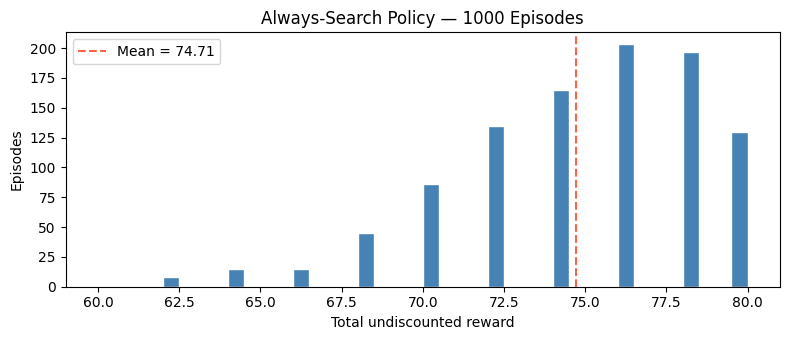

Mean reward: 74.71
Std:         3.93


In [7]:
import numpy as np
import matplotlib.pyplot as plt
def simulate_always_search(n_episodes=1000, n_steps=20):
    total_rewards = []
    for _ in range(n_episodes):
        s = 0  # start at high
        ep_reward = 0.0
        for _ in range(n_steps):
            a = 0  # always search
            next_s = np.random.choice(2, p=T[s, a])
            ep_reward += R[s, a]
            s = next_s
        total_rewards.append(ep_reward)
    return total_rewards

rewards_always_search = simulate_always_search()

plt.figure(figsize=(8, 3.5))
plt.hist(rewards_always_search, bins=40, color='steelblue', edgecolor='white')
plt.axvline(np.mean(rewards_always_search), color='tomato', linestyle='--',
            label=f'Mean = {np.mean(rewards_always_search):.2f}')
plt.xlabel('Total undiscounted reward'); plt.ylabel('Episodes')
plt.title("Always-Search Policy — 1000 Episodes")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Mean reward: {np.mean(rewards_always_search):.2f}")
print(f"Std:         {np.std(rewards_always_search):.2f}")